# Buổi 5 — Adaline & Widrow–Hoff trên C / I / T

Notebook minh họa: đi từ Perceptron (Buổi 4) sang **Adaline (Adaptive Linear Neuron)** và quy tắc học **Widrow–Hoff (LMS)**.

Quy trình: **Predict → Code → Check → Explain**. Trước khi chạy mỗi lượt, hãy ghi dự đoán vào bảng; sau đó chạy các cell Python độc lập ngay trong notebook.

## 1. Perceptron vs Adaline — khác nhau ở đâu?

Cùng dữ liệu C/I/T, cùng một nơ-ron với $\mathbf{w}, b$. Chỉ khác cách dùng output và cách tính sai số.

| | Perceptron (Buổi 4) | Adaline (Buổi 5) |
|---|---|---|
| Output | $\hat y = \mathbb{1}(\text{net} \ge 0)$ (0/1) | $y = \text{net}$ (số thực) |
| Sai số | $e = y_{\text{true}} - \hat y \in \{-1,0,1\}$ | $e = t - \text{net}$ (liên tục) |
| Ý nghĩa | "đúng hay sai?" | "sai bao nhiêu?" |
| Cập nhật | $\mathbf{w} \leftarrow \mathbf{w} + \eta e \mathbf{x}$ | $\mathbf{w} \leftarrow \mathbf{w} + \eta e \mathbf{x}$ |

Công thức cập nhật **giống nhau về hình thức**, nhưng Adaline dùng chính `net` (trước hàm bước) để đo sai số, nên biết được mức độ sai. Đây là nền tảng trực tiếp của gradient descent và backpropagation sau này.

## 2. Mã hóa C / I / T thành 5 feature

| Feature | Ý nghĩa | C | I | T |
|---|---|---:|---:|---:|
| $x_1$ | Nét dọc bên trái | 1 | 0 | 0 |
| $x_2$ | Nét dọc bên phải | 0 | 0 | 0 |
| $x_3$ | Nét ngang phía trên | 1 | 1 | 1 |
| $x_4$ | Nét ngang phía dưới | 1 | 1 | 0 |
| $x_5$ | Nét dọc ở giữa | 0 | 1 | 1 |

Target đo **mức độ giống chữ C**: $t_C = 1$, còn $t_I = t_T = 0$.

$$\mathbf{x}_C = (1,0,1,1,0),\ t_C = 1 \qquad \mathbf{x}_I = (0,0,1,1,1),\ t_I = 0 \qquad \mathbf{x}_T = (0,0,1,0,1),\ t_T = 0$$

## 3. Dự đoán trước khi chạy

Với $\eta = 0.1$, $\mathbf{w}^{(0)} = (0,0,0,0,0)$ và $b^{(0)} = 0$, hãy điền bảng bằng tay trước:

| Lượt | Mẫu | net dự đoán | $e = t - \text{net}$ | $b$ mới |
|---:|---|---:|---:|---:|
| 1 | C |  |  |  |
| 2 | I |  |  |  |
| 3 | T |  |  |  |

## 4. Cài đặt Adaline ngay trong notebook

Cell tiếp theo định nghĩa dữ liệu C/I/T, hàm `net`, quy tắc cập nhật Widrow–Hoff và hàm kiểm tra. Notebook chạy độc lập, không cần file bên ngoài.

In [18]:
import numpy as np

LABELS = ("C", "I", "T")
X = np.array(
    [
        [1, 0, 1, 1, 0],  # C
        [0, 0, 1, 1, 1],  # I
        [0, 0, 1, 0, 1],  # T
    ],
    dtype=float,
)
T = np.array([1.0, 0.0, 0.0])  # target liên tục: mức độ giống C

ETA = 0.1
W0 = np.zeros(X.shape[1], dtype=float)
B0 = 0.0


def net_output(x: np.ndarray, w: np.ndarray, b: float) -> float:
    """Adaline: output chính là net = w·x + b (không qua hàm bước)."""
    return float(np.dot(w, x) + b)


def update(
    x: np.ndarray,
    t: float,
    w: np.ndarray,
    b: float,
    eta: float,
) -> tuple[float, float, np.ndarray, float]:
    """Một lượt Widrow–Hoff: net -> e = t - net -> cập nhật w, b."""
    net = net_output(x, w, b)
    error = t - net
    w_new = w + eta * error * x
    b_new = b + eta * error
    return net, error, w_new, b_new


def mse(w: np.ndarray, b: float) -> float:
    """Sai số bình phương trung bình E = mean(0.5 * e^2) trên cả 3 mẫu."""
    return float(np.mean([0.5 * (t - net_output(x, w, b)) ** 2 for x, t in zip(X, T)]))


def train_one_epoch(eta: float = ETA) -> tuple[np.ndarray, float, list[dict[str, object]]]:
    """Chạy đúng một epoch theo thứ tự C, I, T và lưu lịch sử."""
    w = W0.copy()
    b = B0
    history: list[dict[str, object]] = []
    for label, x_i, t_i in zip(LABELS, X, T):
        net, error, w, b = update(x_i, float(t_i), w, b, eta)
        history.append(
            {
                "mau": label,
                "net": net,
                "error": error,
                "w_sau_luot": w.copy(),
                "b_sau_luot": b,
            }
        )
    return w, b, history


def run_checks() -> None:
    """Đối chiếu với bảng tính tay trong bài giảng Buổi 5."""
    w_final, b_final, history = train_one_epoch()
    nets = [row["net"] for row in history]
    assert np.isclose(nets[0], 0.0), "net của C phải bằng 0."
    assert np.isclose(nets[1], 0.3), "net của I phải bằng 0.3."
    assert np.isclose(nets[2], 0.11), "net của T phải bằng 0.11."
    assert np.allclose(w_final, [0.1, 0.0, 0.059, 0.07, -0.041]), "w sau 1 epoch chưa đúng."
    assert np.isclose(b_final, 0.059), "b sau 1 epoch chưa đúng."


print("Đã định nghĩa Adaline C/I/T ngay trong notebook.")

Đã định nghĩa Adaline C/I/T ngay trong notebook.


In [2]:
run_checks()
print('✓ Các kiểm tra Adaline đã vượt qua.')

✓ Các kiểm tra Adaline đã vượt qua.


## 5. Đối chiếu một epoch với bảng tính tay

In [19]:
import pandas as pd

w_final, b_final, history = train_one_epoch()

rows_for_display = []
for turn, row in enumerate(history, start=1):
    rows_for_display.append(
        {
            "Lượt": turn,
            "Mẫu": row["mau"],
            "net": f'{row["net"]:.3f}',
            "t": f'{float(T[turn - 1]):.1f}',
            "e = t - net": f'{row["error"]:.3f}',
            "w sau lượt": np.array2string(row["w_sau_luot"], precision=3, separator=", "),
            "b sau lượt": f'{row["b_sau_luot"]:.3f}',
        }
    )

comparison_table = pd.DataFrame(rows_for_display)
display(comparison_table)
print(f'w cuối = {np.array2string(w_final, precision=3, separator=", ")}')
print(f'b cuối = {b_final:.3f}')
print(f'MSE sau 1 epoch = {mse(w_final, b_final):.6f}')

,Lượt,Mẫu,net,t,e = t - net,w sau lượt,b sau lượt
0,1,C,0.000,1.0,1.000,"[0.1, 0. , 0.1, 0.1, 0. ]",0.100
1,2,I,0.300,0.0,-0.300,"[ 0.1 , 0. , 0.07, 0.07, -0.03]",0.070
2,3,T,0.110,0.0,-0.110,"[ 0.1 , 0. , 0.059, 0.07 , -0.041]",0.059


w cuối = [ 0.1  ,  0.   ,  0.059,  0.07 , -0.041]
b cuối = 0.059
MSE sau 1 epoch = 0.089080


**Giải thích bằng lời:**

- Lượt C: net = 0 nhưng target = 1 → sai số dương lớn, mạng **tăng** trọng số các feature đang bật trong C ($x_1, x_3, x_4$).
- Lượt I: net = 0.3 > 0 nhưng target = 0 → sai số âm, mạng **giảm** trọng số các feature bật trong I (đặc biệt $x_5$ nét dọc giữa).
- Lượt T: net = 0.11 vẫn hơi dương → tiếp tục giảm nhẹ $x_3, x_5$.
- Sau 3 mẫu, $w_1$ (nét dọc trái, chỉ C mới có) vẫn dương và lớn nhất — dấu hiệu mạnh nhất của chữ C.

## 6. Huấn luyện nhiều epoch — quan sát MSE hội tụ

Adaline dùng sai số liên tục nên có thể theo dõi MSE giảm dần qua các epoch.

In [20]:
def train_many_epochs(n_epochs: int = 30, eta: float = ETA):
    w = W0.copy()
    b = B0
    mse_history = []

    for _ in range(n_epochs):
        for x_i, t_i in zip(X, T):
            _, _, w, b = update(x_i, float(t_i), w, b, eta)

        mse_history.append(mse(w, b))

    return w, b, mse_history


w_many, b_many, mse_history = train_many_epochs()

print(f'MSE epoch 1  = {mse_history[0]:.6f}')
print(f'MSE epoch 5  = {mse_history[4]:.6f}')
print(f'MSE epoch 30 = {mse_history[-1]:.6f}')
print(f'w cuối = {np.array2string(w_many, precision=3, separator=", ")}')
print(f'b cuối = {b_many:.3f}')
print('net cuối cho C/I/T:', [round(net_output(x, w_many, b_many), 3) for x in X])

assert mse_history[-1] < mse_history[0], 'MSE phải giảm sau nhiều epoch.'

MSE epoch 1  = 0.089080
MSE epoch 5  = 0.021917
MSE epoch 30 = 0.000647
w cuối = [ 0.551,  0.   ,  0.173,  0.081, -0.378]
b cuối = 0.173
net cuối cho C/I/T: [0.978, 0.048, -0.032]


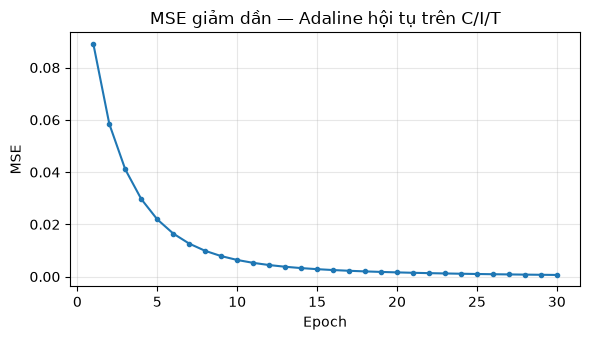

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3.5))
plt.plot(range(1, len(mse_history) + 1), mse_history, marker='o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('MSE giảm dần — Adaline hội tụ trên C/I/T')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Thí nghiệm learning rate

Chạy 30 epoch với nhiều $\eta$. Quan sát: $\eta$ quá lớn có thể làm MSE dao động/phân kỳ thay vì giảm mượt.

In [21]:
for eta in (0.02, 0.1, 0.3, 0.6):
    _, _, hist = train_many_epochs(n_epochs=30, eta=eta)
    print(f'eta={eta:<4}: MSE đầu={hist[0]:.5f}  MSE cuối={hist[-1]:.5f}')

eta=0.02: MSE đầu=0.14329  MSE cuối=0.02089
eta=0.1 : MSE đầu=0.08908  MSE cuối=0.00065
eta=0.3 : MSE đầu=0.03913  MSE cuối=0.00000
eta=0.6 : MSE đầu=0.72670  MSE cuối=2030201.53891


**Kết luận:** khi $\eta$ nhỏ, MSE giảm chậm nhưng ổn định; khi $\eta$ lớn, mỗi bước cập nhật mạnh hơn nhưng dễ dao động. Có một khoảng $\eta$ hợp lý để hội tụ nhanh mà vẫn ổn định.

> Viết nhận xét 2–3 dòng của bạn tại đây.

## 8. Từ số thực về quyết định 0/1

Adaline cho ra số thực (mức độ giống C). Muốn ra nhãn cứng, ta đặt ngưỡng, ví dụ $\hat y = 1$ nếu $y \ge 0.5$.

In [22]:
nguong = 0.5
for label, x_i, t_i in zip(LABELS, X, T):
    y = net_output(x_i, w_many, b_many)
    y_hat = int(y >= nguong)
    print(f'{label}: y={y:.3f} -> ŷ={y_hat} (target={int(t_i)})')

C: y=0.978 -> ŷ=1 (target=1)
I: y=0.048 -> ŷ=0 (target=0)
T: y=-0.032 -> ŷ=0 (target=0)


## 9. Tóm mạch từ trên xuống

1. **Nhập dữ liệu**: mã hóa C/I/T thành vector feature $\mathbf{x}$ và target $t$.
2. **Tính net**: $\text{net} = \mathbf{w}^\top \mathbf{x} + b$; với Adaline, output $y = \text{net}$.
3. **Đo sai số**: $e = t - \text{net}$ (liên tục, biết "sai bao nhiêu").
4. **Sửa trọng số**: $\mathbf{w} \leftarrow \mathbf{w} + \eta e \mathbf{x}$, $b \leftarrow b + \eta e$.
5. **Lặp nhiều epoch**: theo dõi MSE giảm dần → mạng hội tụ.

Đây chính là quy tắc Widrow–Hoff (LMS) — một dạng gradient descent trên hàm lỗi bình phương, tiền đề của backpropagation trong MLP.